# Classificação de Tickets de Incidentes com LLM — Versão Offline

**Estudo de Caso 2 — Minicurso "Inteligência Artificial aplicada à Resposta a Incidentes"**

## Sobre este notebook

Diferente do notebook principal (`02-classificacao.ipynb`), este aqui
**não depende de nada externo**:

- ❌ Sem chave de API (Gemini ou qualquer outro provedor)
- ❌ Sem conexão à internet
- ❌ Sem arquivos CSV externos — os tickets estão **embutidos diretamente no código**
- ✅ Só precisa de `pandas` e `matplotlib` — bibliotecas padrão, quase certamente já
  instaladas em qualquer ambiente Python usado para ciência de dados

Todos os resultados mostrados aqui são **reais** — vêm de uma execução completa dos
24 tickets, nas quatro estratégias de prompt: livre, zero-shot, few-shot com 2 e com
7 exemplos. Use este notebook sempre que não tiver acesso a uma chave de API ou à
internet.

Se tiver acesso à API, prefira o notebook principal — ele executa as classificações
em tempo real, o que ajuda a acompanhar o processo passo a passo.


## 1. Preparação

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11

print("Ambiente pronto — nenhuma dependência externa além de pandas e matplotlib.")


Ambiente pronto — nenhuma dependência externa além de pandas e matplotlib.


## 2. Taxonomia de referência

As 12 categorias usadas neste notebook seguem a consolidação proposta por
Severo et al. (2025), com base nas diretrizes de tratamento de incidentes do
NIST SP 800-61 Rev. 3.


In [2]:
TAXONOMIA = {
    "CAT1":  "Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores",
    "CAT2":  "Malware — infecção por código malicioso que compromete dispositivos ou dados",
    "CAT3":  "Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes",
    "CAT4":  "Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis",
    "CAT5":  "Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos",
    "CAT6":  "Abuso Interno — ações intencionais ou negligentes de usuários internos",
    "CAT7":  "Engenharia Social — engano de pessoas para obter acesso ou informações",
    "CAT8":  "Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais",
    "CAT9":  "Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações",
    "CAT10": "Uso Indevido de Recursos — uso não autorizado de sistemas para outros fins",
    "CAT11": "Problema de Fornecedor/Terceiro — incidente originado por falha de segurança de terceiros",
    "CAT12": "Tentativa de Intrusão — tentativas hostis de invasão ainda não confirmadas como bem-sucedidas",
}

for cod, desc in TAXONOMIA.items():
    print(f"{cod}: {desc}")


CAT1: Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores
CAT2: Malware — infecção por código malicioso que compromete dispositivos ou dados
CAT3: Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes
CAT4: Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis
CAT5: Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos
CAT6: Abuso Interno — ações intencionais ou negligentes de usuários internos
CAT7: Engenharia Social — engano de pessoas para obter acesso ou informações
CAT8: Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais
CAT9: Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações
CAT10: Uso Indevido de Recursos — uso não autorizado de sistemas para outros fins
CAT11: Problema de Fornecedor/Terceiro — incidente originado por falha de segurança de terceiros
CAT12: Tentativ

## 3. Tickets ilustrativos (embutidos — sem necessidade de CSV)

Quatro tickets do conjunto de avaliação e três exemplos usados nos prompts
few-shot — os que melhor ilustram os pontos discutidos ao longo deste notebook.


In [3]:
# --- Tickets de avaliação (protagonistas da história) ---

TICKET_T001 = {
    "id": "T001",
    "categoria": "CAT5",
    "texto": (
        "De: cert@certificado.exemplo.br\n"
        "Para: seguranca@universidade.exemplo.br (Joana Ribeiro Alves)\n"
        "Assunto: Servidor DNS recursivo aberto - risco de amplificacao DDoS\n\n"
        "Prezados, identificamos que o host srv-dns-02.universidade.exemplo.br "
        "(203.0.113.55, ASN 64512) responde a consultas DNS recursivas originadas de "
        "qualquer endereco na Internet. Essa configuracao permite que o servidor seja "
        "usado como amplificador em ataques de negacao de servico distribuida.\n\n"
        "Solicitamos restricao da recursao as redes internas em ate 72 horas."
    ),
}

TICKET_T022 = {
    "id": "T022",
    "categoria": "CAT4",
    "texto": (
        "Exposicao de credenciais em repositorio publico\n\n"
        "Varredura automatizada identificou, no repositorio publico "
        "github.com/exemplo-org/sistema-protocolo, um arquivo config/database.yml com "
        "credenciais validas do banco de producao e a chave de API do servico de "
        "assinatura digital.\n\n"
        "Commit responsavel: 7c1e9f2, autoria de Diego Almeida Fontoura. O historico "
        "foi reescrito, o repositorio tornado privado e todas as credenciais "
        "rotacionadas."
    ),
}

TICKET_T024 = {
    "id": "T024",
    "categoria": "CAT5",
    "texto": (
        "Assunto: atividade incomum no servidor de aplicacao\n\n"
        "Boa tarde. Notamos algo estranho no servidor app-03. O uso de memoria subiu "
        "muito ontem a noite e apareceram uns processos que ninguem reconhece. Um "
        "colega disse que pode ser coisa do sistema mesmo, mas achei melhor abrir o "
        "chamado.\n\n"
        "Nao sei dizer se alguem mexeu na configuracao."
    ),
}

# --- Exemplos usados nos prompts few-shot ---

EXEMPLO_T025 = {
    "categoria": "CAT5",
    "texto": (
        "Relatorio de varredura de seguranca - servidor Memcached exposto\n\n"
        "Verificamos que o servidor cache-02.instituto.exemplo.br expoe o servico "
        "Memcached diretamente a Internet, sem autenticacao. Essa configuracao e "
        "classificada como vulnerabilidade critica, pois permite fator de "
        "amplificacao de ate 10.000x em ataques de negacao de servico. Nenhum "
        "trafego anomalo foi registrado ate o momento; achado preventivo de rotina."
    ),
}

EXEMPLO_T026 = {
    "categoria": "CAT3",
    "texto": (
        "Indisponibilidade do sistema de matricula online\n\n"
        "O sistema ficou completamente inacessivel apos pico de 8,4 Gbps de trafego "
        "UDP recebido na borda, com origem distribuida em mais de 3.000 enderecos "
        "IP, caracteristico de ataque de amplificacao. Mitigacao aplicada via "
        "scrubbing center. Nenhuma vulnerabilidade interna identificada como causa."
    ),
}

EXEMPLO_T031 = {
    "categoria": "CAT4",
    "texto": (
        "Configuracao indevida expoe backups de sistema academico em nuvem\n\n"
        "Um administrador de TI reconfigurou por engano as permissoes de um bucket "
        "de backups, deixando-o acessivel publicamente. A falha foi identificada 6 "
        "dias depois por um scanner automatizado de terceiros. Nao ha evidencia de "
        "ma-fe; tratou-se de erro de configuracao durante manutencao de rotina."
    ),
}

print("Tickets embutidos com sucesso.")


Tickets embutidos com sucesso.


## 4. Classificação livre (sem taxonomia) — por que definir uma taxonomia?

Antes de comparar zero-shot e few-shot (que sempre usam a taxonomia de 12 categorias),
vale mostrar o que acontece **sem** ela: o modelo recebe só o ticket e nomeia o
incidente com as próprias palavras. Os dados abaixo são reais, de uma execução
completa dos 24 tickets.


In [4]:
# id: (esperado, rótulo livre — dados reais de uma execução completa)
RESULTADOS_LIVRE = {
    "T001": ("CAT5",  "Configuração Insegura de Serviço"),
    "T002": ("CAT12", "Ataque de força bruta"),
    "T003": ("CAT3",  "Ataque de Negação de Serviço"),
    "T004": ("CAT2",  "Infecção por Malware"),
    "T005": ("CAT7",  "Phishing de credenciais"),
    "T006": ("CAT1",  "Comprometimento de conta"),
    "T007": ("CAT5",  "Vulnerabilidade Crítica Exposta"),
    "T008": ("CAT9",  "Violação de controle de acesso"),
    "T009": ("CAT4",  "Vazamento de dados sensíveis"),
    "T010": ("CAT12", "Reconhecimento de rede"),
    "T011": ("CAT10", "Mineração ilícita de criptomoedas"),
    "T012": ("CAT11", "Vazamento de dados"),
    "T013": ("CAT5",  "Vulnerabilidade de injeção SQL"),
    "T014": ("CAT3",  "Ataque de negação de serviço"),
    "T015": ("CAT2",  "Ataque de Ransomware"),
    "T016": ("CAT6",  "Uso indevido de privilégios"),
    "T017": ("CAT5",  "Vulnerabilidade de Reflexão"),
    "T018": ("CAT12", "Exploração de vulnerabilidade"),
    "T019": ("CAT8",  "Desastre físico ambiental"),
    "T020": ("CAT9",  "Comprometimento de aplicação web"),
    "T021": ("CAT7",  "Engenharia Social / Phishing"),
    "T022": ("CAT4",  "Vazamento de credenciais"),
    "T023": ("CAT3",  "Ataque de Negação de Serviço"),
    "T024": ("CAT5",  "Suspeita de comprometimento"),
}

df_livre = pd.DataFrame(
    [(tid, esp, rot) for tid, (esp, rot) in RESULTADOS_LIVRE.items()],
    columns=["id", "esperado", "rotulo_livre"],
)

rotulos_normalizados = df_livre["rotulo_livre"].str.lower().str.strip()
distintos = rotulos_normalizados.nunique()
print(f"{distintos} rótulos distintos (ignorando maiúsculas/minúsculas) para {len(df_livre)} tickets.")
print("A taxonomia estruturada usa apenas 12 categorias fixas.")


22 rótulos distintos (ignorando maiúsculas/minúsculas) para 24 tickets.
A taxonomia estruturada usa apenas 12 categorias fixas.


In [5]:
# Dispersão por grupo: tickets que compartilham a MESMA categoria NIST real
linhas_dispersao = []
for cat, grupo in df_livre.groupby("esperado"):
    if len(grupo) > 1:
        rotulos = grupo["rotulo_livre"].tolist()
        n_distintos = grupo["rotulo_livre"].str.lower().str.strip().nunique()
        linhas_dispersao.append({
            "categoria": cat,
            "tickets": len(grupo),
            "rótulos usados": " | ".join(rotulos),
            "distintos": n_distintos,
            "dispersão": n_distintos / len(grupo),
        })

df_dispersao = pd.DataFrame(linhas_dispersao).sort_values("dispersão", ascending=False)


def colorir_dispersao(val):
    if isinstance(val, float):
        intensidade = int(255 - val * 120)
        return f"background-color: rgb(255, {intensidade}, {intensidade})"
    return ""


(
    df_dispersao
    .style
    .format({"dispersão": "{:.0%}"})
    .map(colorir_dispersao, subset=["dispersão"])
    .set_caption("Dispersão semântica por categoria real (100% = todo ticket recebeu rótulo diferente)")
    .hide(axis="index")
)


categoria,tickets,rótulos usados,distintos,dispersão
CAT12,3,Ataque de força bruta | Reconhecimento de rede | Exploração de vulnerabilidade,3,100%
CAT2,2,Infecção por Malware | Ataque de Ransomware,2,100%
CAT4,2,Vazamento de dados sensíveis | Vazamento de credenciais,2,100%
CAT7,2,Phishing de credenciais | Engenharia Social / Phishing,2,100%
CAT5,5,Configuração Insegura de Serviço | Vulnerabilidade Crítica Exposta | Vulnerabilidade de injeção SQL | Vulnerabilidade de Reflexão | Suspeita de comprometimento,5,100%
CAT9,2,Violação de controle de acesso | Comprometimento de aplicação web,2,100%
CAT3,3,Ataque de Negação de Serviço | Ataque de negação de serviço | Ataque de Negação de Serviço,1,33%


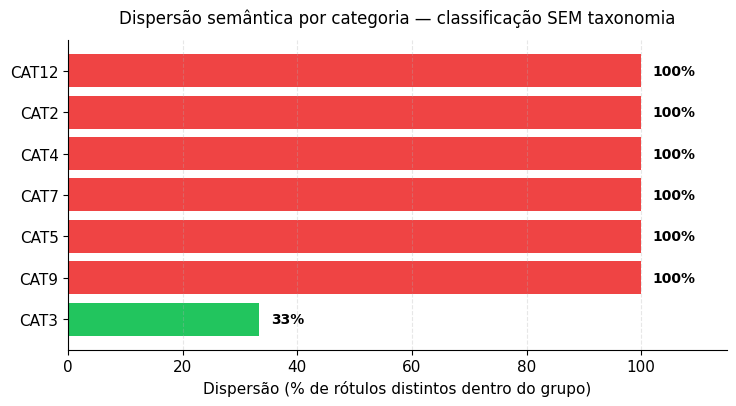

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
cores_disp = ["#ef4444" if d == 1.0 else "#22c55e" for d in df_dispersao["dispersão"]]
barras = ax.barh(df_dispersao["categoria"], df_dispersao["dispersão"] * 100, color=cores_disp)

for barra, valor in zip(barras, df_dispersao["dispersão"] * 100):
    ax.text(valor + 2, barra.get_y() + barra.get_height() / 2, f"{valor:.0f}%",
            va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0, 115)
ax.set_xlabel("Dispersão (% de rótulos distintos dentro do grupo)")
ax.set_title("Dispersão semântica por categoria — classificação SEM taxonomia", fontsize=12, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


### O que os dados reais mostram

- **22 rótulos distintos para 24 tickets** — o modelo praticamente nunca repete a
  mesma redação, mesmo classificando incidentes do mesmo tipo real.
- **6 dos 7 grupos com 2+ tickets tiveram dispersão total (100%)** — cada ticket
  recebeu um rótulo diferente, mesmo sendo a mesma categoria NIST. O caso mais
  extremo é o **CAT5** (5 tickets): "Configuração Insegura de Serviço",
  "Vulnerabilidade Crítica Exposta", "Vulnerabilidade de injeção SQL",
  "Vulnerabilidade de Reflexão" e "Suspeita de comprometimento" — cinco descrições
  diferentes para a mesma categoria real.
- **Só o grupo CAT3 convergiu** — os três tickets de negação de serviço receberam
  praticamente a mesma redação ("Ataque de Negação de Serviço"). É a exceção, não a
  regra.

Isso é a dispersão semântica na prática: sem uma taxonomia fixa, é impossível agregar
esses resultados em métricas, dashboards ou relatórios consistentes — mesmo que o
modelo "entenda" corretamente o tipo de incidente em cada caso individual.


## 5. Como é o prompt zero-shot, na prática

Mesmo sem chamar a API, vale mostrar o prompt exato que seria enviado — é
educativo por si só.


In [7]:
def montar_prompt_zero_shot(ticket_texto: str, taxonomia: dict) -> str:
    categorias_str = "\n".join(f"- {cod}: {desc}" for cod, desc in taxonomia.items())
    return f"""Você é um analista de SOC especialista em categorização de incidentes de segurança.

Classifique o ticket abaixo em UMA das categorias a seguir, segundo o NIST SP 800-61 Rev. 3:

{categorias_str}

Ticket:
\"\"\"
{ticket_texto}
\"\"\"

Responda em formato JSON, apenas com as chaves "categoria" (o código, ex: CAT1) e "justificativa" (uma frase curta)."""


print(montar_prompt_zero_shot(TICKET_T001["texto"], TAXONOMIA))


Você é um analista de SOC especialista em categorização de incidentes de segurança.

Classifique o ticket abaixo em UMA das categorias a seguir, segundo o NIST SP 800-61 Rev. 3:

- CAT1: Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores
- CAT2: Malware — infecção por código malicioso que compromete dispositivos ou dados
- CAT3: Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes
- CAT4: Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis
- CAT5: Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos
- CAT6: Abuso Interno — ações intencionais ou negligentes de usuários internos
- CAT7: Engenharia Social — engano de pessoas para obter acesso ou informações
- CAT8: Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais
- CAT9: Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configuraçõ

## 6. Como é o prompt few-shot, na prática

Prompt com o exemplo híbrido T031 (o que corrigiu o T022 na versão real) incluído.


In [8]:
def montar_prompt_few_shot(ticket_texto: str, taxonomia: dict, exemplos: list) -> str:
    categorias_str = "\n".join(f"- {cod}: {desc}" for cod, desc in taxonomia.items())
    exemplos_str = "\n\n".join(
        f'Ticket: \"{ex["texto"][:200]}...\"\nResposta: {{"categoria": "{ex["categoria"]}"}}'
        for ex in exemplos
    )
    return f"""Você é um analista de SOC especialista em categorização de incidentes de segurança.

Classifique o ticket em UMA das categorias a seguir, segundo o NIST SP 800-61 Rev. 3:

{categorias_str}

Veja alguns exemplos já classificados:

{exemplos_str}

Agora classifique o novo ticket:
\"\"\"
{ticket_texto}
\"\"\"

Responda em formato JSON, apenas com as chaves "categoria" (o código, ex: CAT1) e "justificativa" (uma frase curta)."""


print(montar_prompt_few_shot(TICKET_T022["texto"], TAXONOMIA, [EXEMPLO_T025, EXEMPLO_T031]))


Você é um analista de SOC especialista em categorização de incidentes de segurança.

Classifique o ticket em UMA das categorias a seguir, segundo o NIST SP 800-61 Rev. 3:

- CAT1: Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores
- CAT2: Malware — infecção por código malicioso que compromete dispositivos ou dados
- CAT3: Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes
- CAT4: Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis
- CAT5: Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos
- CAT6: Abuso Interno — ações intencionais ou negligentes de usuários internos
- CAT7: Engenharia Social — engano de pessoas para obter acesso ou informações
- CAT8: Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais
- CAT9: Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações
- CA

## 7. Resultados reais — os 24 tickets, três estratégias

Estes valores vêm de uma execução real e completa dos 24 tickets:
**zero-shot → few-shot (2 exemplos) → few-shot (7 exemplos)**.


In [9]:
# esperado, zero-shot, few-shot(2 ex.), few-shot(7 ex.) — dados reais
RESULTADOS = {
    "T001": ("CAT5",  "CAT12", "CAT5",  "CAT5"),
    "T002": ("CAT12", "CAT12", "CAT12", "CAT12"),
    "T003": ("CAT3",  "CAT3",  "CAT3",  "CAT3"),
    "T004": ("CAT2",  "CAT2",  "CAT2",  "CAT2"),
    "T005": ("CAT7",  "CAT7",  "CAT7",  "CAT7"),
    "T006": ("CAT1",  "CAT1",  "CAT1",  "CAT1"),
    "T007": ("CAT5",  "CAT5",  "CAT5",  "CAT5"),
    "T008": ("CAT9",  "CAT9",  "CAT9",  "CAT9"),
    "T009": ("CAT4",  "CAT4",  "CAT4",  "CAT4"),
    "T010": ("CAT12", "CAT12", "CAT12", "CAT12"),
    "T011": ("CAT10", "CAT10", "CAT10", "CAT10"),
    "T012": ("CAT11", "CAT11", "CAT11", "CAT11"),
    "T013": ("CAT5",  "CAT5",  "CAT5",  "CAT5"),
    "T014": ("CAT3",  "CAT3",  "CAT3",  "CAT3"),
    "T015": ("CAT2",  "CAT2",  "CAT2",  "CAT2"),
    "T016": ("CAT6",  "CAT6",  "CAT6",  "CAT6"),
    "T017": ("CAT5",  "CAT3",  "CAT5",  "CAT5"),
    "T018": ("CAT12", "CAT12", "CAT12", "CAT12"),
    "T019": ("CAT8",  "CAT8",  "CAT8",  "CAT8"),
    "T020": ("CAT9",  "CAT9",  "CAT9",  "CAT9"),
    "T021": ("CAT7",  "CAT7",  "CAT7",  "CAT7"),
    "T022": ("CAT4",  "CAT4",  "CAT6",  "CAT4"),
    "T023": ("CAT3",  "CAT3",  "CAT3",  "CAT3"),
    "T024": ("CAT5",  "CAT2",  "CAT2",  "CAT2"),
}

df_resultados = pd.DataFrame(
    [(tid, *vals) for tid, vals in RESULTADOS.items()],
    columns=["id", "esperado", "zero_shot", "few_shot_2", "few_shot_7"],
)

for col in ["zero_shot", "few_shot_2", "few_shot_7"]:
    df_resultados[f"{col}_ok"] = df_resultados[col] == df_resultados["esperado"]

df_resultados


,id,esperado,zero_shot,few_shot_2,few_shot_7,zero_shot_ok,few_shot_2_ok,few_shot_7_ok
0,T001,CAT5,CAT12,CAT5,CAT5,False,True,True
1,T002,CAT12,CAT12,CAT12,CAT12,True,True,True
2,T003,CAT3,CAT3,CAT3,CAT3,True,True,True
3,T004,CAT2,CAT2,CAT2,CAT2,True,True,True
4,T005,CAT7,CAT7,CAT7,CAT7,True,True,True
5,T006,CAT1,CAT1,CAT1,CAT1,True,True,True
6,T007,CAT5,CAT5,CAT5,CAT5,True,True,True
7,T008,CAT9,CAT9,CAT9,CAT9,True,True,True
8,T009,CAT4,CAT4,CAT4,CAT4,True,True,True
9,T010,CAT12,CAT12,CAT12,CAT12,True,True,True


In [10]:
def colorir_resultado(val):
    if val is True:
        return "background-color: #d4edda; color: #155724"
    elif val is False:
        return "background-color: #f8d7da; color: #721c24"
    return ""

colunas_exibir = ["id", "esperado", "zero_shot", "few_shot_2", "few_shot_7",
                   "zero_shot_ok", "few_shot_2_ok", "few_shot_7_ok"]

(
    df_resultados[colunas_exibir]
    .style
    .map(colorir_resultado, subset=["zero_shot_ok", "few_shot_2_ok", "few_shot_7_ok"])
    .set_caption("Resultado por ticket — verde = acerto, vermelho = erro")
)


,id,esperado,zero_shot,few_shot_2,few_shot_7,zero_shot_ok,few_shot_2_ok,few_shot_7_ok
0,T001,CAT5,CAT12,CAT5,CAT5,False,True,True
1,T002,CAT12,CAT12,CAT12,CAT12,True,True,True
2,T003,CAT3,CAT3,CAT3,CAT3,True,True,True
3,T004,CAT2,CAT2,CAT2,CAT2,True,True,True
4,T005,CAT7,CAT7,CAT7,CAT7,True,True,True
5,T006,CAT1,CAT1,CAT1,CAT1,True,True,True
6,T007,CAT5,CAT5,CAT5,CAT5,True,True,True
7,T008,CAT9,CAT9,CAT9,CAT9,True,True,True
8,T009,CAT4,CAT4,CAT4,CAT4,True,True,True
9,T010,CAT12,CAT12,CAT12,CAT12,True,True,True


## 8. Acurácia por estratégia

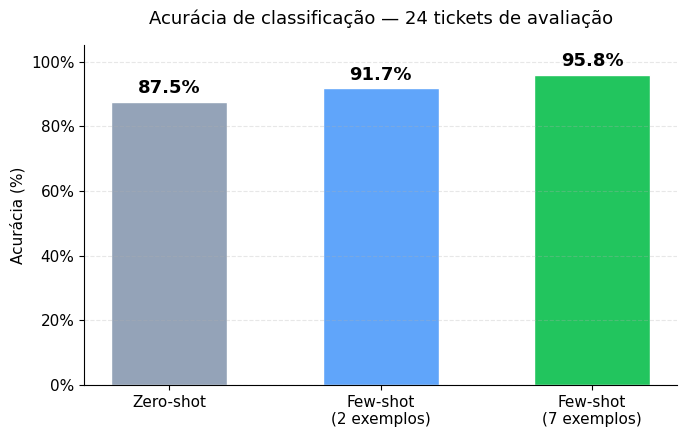

In [11]:
tecnicas = ["Zero-shot", "Few-shot\n(2 exemplos)", "Few-shot\n(7 exemplos)"]
acuracias = [
    df_resultados["zero_shot_ok"].mean() * 100,
    df_resultados["few_shot_2_ok"].mean() * 100,
    df_resultados["few_shot_7_ok"].mean() * 100,
]
cores = ["#94a3b8", "#60a5fa", "#22c55e"]

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(tecnicas, acuracias, color=cores, width=0.55, edgecolor="white")

for barra, valor in zip(barras, acuracias):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 1.5, f"{valor:.1f}%",
            ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_ylim(0, 105)
ax.set_ylabel("Acurácia (%)")
ax.set_title("Acurácia de classificação — 24 tickets de avaliação", fontsize=13, pad=15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


## 8.1 Matriz de confusão

Com 24 tickets distribuídos por até 12 categorias, a maioria das células desta
matriz terá 0, 1 ou 2 ocorrências — não é uma amostra estatisticamente robusta
para revelar padrões sistemáticos de confusão. Mesmo assim, ela visualiza
concretamente os erros reais observados: CAT5 confundido com CAT12, CAT3 ou
CAT2, e CAT4 confundido com CAT6.


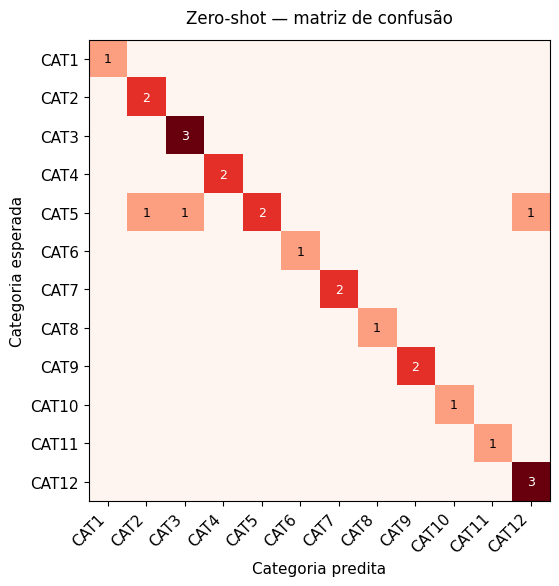

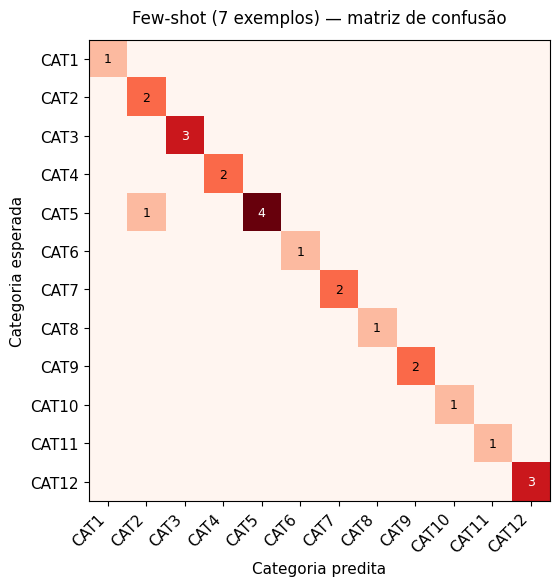

In [12]:
def plotar_matriz_confusao(df_r: pd.DataFrame, coluna_predita: str, titulo: str):
    categorias = sorted(
        set(df_r["esperado"]) | set(df_r[coluna_predita].dropna()),
        key=lambda c: int(c.replace("CAT", "")),
    )
    matriz = pd.crosstab(df_r["esperado"], df_r[coluna_predita]).reindex(
        index=categorias, columns=categorias, fill_value=0
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(matriz.values, cmap="Reds")

    ax.set_xticks(range(len(categorias)))
    ax.set_yticks(range(len(categorias)))
    ax.set_xticklabels(categorias, rotation=45, ha="right")
    ax.set_yticklabels(categorias)
    ax.set_xlabel("Categoria predita")
    ax.set_ylabel("Categoria esperada")
    ax.set_title(titulo, fontsize=12, pad=12)

    for i in range(len(categorias)):
        for j in range(len(categorias)):
            valor = matriz.values[i, j]
            if valor > 0:
                cor_texto = "white" if valor > matriz.values.max() / 2 else "black"
                ax.text(j, i, str(valor), ha="center", va="center", color=cor_texto, fontsize=9)

    plt.tight_layout()
    plt.show()


plotar_matriz_confusao(df_resultados, "zero_shot", "Zero-shot — matriz de confusão")
plotar_matriz_confusao(df_resultados, "few_shot_7", "Few-shot (7 exemplos) — matriz de confusão")


## 8.2 O arquivo que alimenta a Prática 3

O resultado final desta prática — a categoria atribuída pela melhor estratégia
avaliada (few-shot com 7 exemplos) — seria salvo em
`saida/incidentes_classificados.csv`, alimentando a Prática 3 (geração de
playbooks). Como este notebook não tem acesso aos textos completos dos 24
tickets (só os embutidos na Seção 3), a tabela abaixo mostra a estrutura que
o notebook principal gera de fato.


In [13]:
saida_pratica3_exemplo = df_resultados[["id", "esperado", "few_shot_7"]].rename(
    columns={"few_shot_7": "categoria_atribuida"}
)
saida_pratica3_exemplo["correto"] = saida_pratica3_exemplo["esperado"] == saida_pratica3_exemplo["categoria_atribuida"]

print("Estrutura de saida/incidentes_classificados.csv (gerado pelo notebook principal):")
saida_pratica3_exemplo.head()


Estrutura de saida/incidentes_classificados.csv (gerado pelo notebook principal):


,id,esperado,categoria_atribuida,correto
0,T001,CAT5,CAT5,True
1,T002,CAT12,CAT12,True
2,T003,CAT3,CAT3,True
3,T004,CAT2,CAT2,True
4,T005,CAT7,CAT7,True


## 9. A história em 4 tickets

Quatro tickets contam toda a narrativa desta demonstração: dois corrigidos pelo
primeiro par de exemplos, um corrigido só pelo exemplo híbrido, e um que resistiu a
tudo.


In [14]:
historia = {
    "T001": ("CAT5",  "CAT12", "CAT5",  "CAT5",  "Corrigido pelo par CAT5/CAT3"),
    "T017": ("CAT5",  "CAT3",  "CAT5",  "CAT5",  "Corrigido pelo par CAT5/CAT3"),
    "T022": ("CAT4",  "CAT4",  "CAT6",  "CAT4",  "Só corrigido pelo exemplo híbrido T031"),
    "T024": ("CAT5",  "CAT2",  "CAT2",  "CAT2",  "Resistente em TODAS as técnicas — problema é o relato, não o prompt"),
}

df_historia = pd.DataFrame(
    [(tid, *vals) for tid, vals in historia.items()],
    columns=["id", "esperado", "zero_shot", "few_shot_2", "few_shot_7", "observação"],
)

for col in ["zero_shot", "few_shot_2", "few_shot_7"]:
    df_historia[f"{col}_ok"] = df_historia[col] == df_historia["esperado"]

(
    df_historia[["id", "esperado", "zero_shot", "few_shot_2", "few_shot_7", "observação"]]
    .style
    .apply(lambda row: [
        "" , "",
        colorir_resultado(df_historia.loc[row.name, "zero_shot_ok"]),
        colorir_resultado(df_historia.loc[row.name, "few_shot_2_ok"]),
        colorir_resultado(df_historia.loc[row.name, "few_shot_7_ok"]),
        "",
    ], axis=1)
    .set_caption("Os quatro tickets que contam a história desta demonstração")
)


,id,esperado,zero_shot,few_shot_2,few_shot_7,observação
0,T001,CAT5,CAT12,CAT5,CAT5,Corrigido pelo par CAT5/CAT3
1,T017,CAT5,CAT3,CAT5,CAT5,Corrigido pelo par CAT5/CAT3
2,T022,CAT4,CAT4,CAT6,CAT4,Só corrigido pelo exemplo híbrido T031
3,T024,CAT5,CAT2,CAT2,CAT2,"Resistente em TODAS as técnicas — problema é o relato, não o prompt"


## 10. Discussão

### O que este material demonstra sobre o AutoClass

O zero-shot é, estruturalmente, a abordagem que o **AutoClass** usa em produção: uma
única chamada ao LLM por classificação, com contexto recuperado via RAG. Confirmado
diretamente no código-fonte público (`github.com/gt-rnp-lfi/lfi-autoclass`). A
ferramenta está em atualização contínua e irá incorporar novas técnicas de prompt
nas próximas versões.

### A progressão real: 87,5% → 91,7% → 95,8%

- **Zero-shot (87,5%)** erra 3 tickets: T001, T017 (confundem CAT5 com outras
  categorias) e T024 (relato vago).
- **Few-shot com 2 exemplos (91,7%)** — um único par de exemplos contrastantes
  (CAT5 vs. CAT3) corrige T001 e T017 de uma vez. Mas introduz um erro novo: T022
  (CAT4 confundido com CAT6, abuso interno).
- **Few-shot com 7 exemplos (95,8%)** — a análise do erro em T022 revelou um padrão
  específico: causa **interna** (erro de um funcionário) com efeito de exposição
  **externa** (achado por terceiros). Um exemplo desenhado exatamente para esse
  padrão híbrido (T031) corrigiu o T022.
- **T024 nunca foi corrigido**, em nenhuma das três estratégias — evidência de que o
  problema é a qualidade do relato original ("atividade incomum", sem detalhes
  técnicos), não a estratégia de prompting. Conecta com a discussão sobre qualidade
  do alerta de entrada (Alahmadi et al.).

### Fechando em três camadas: livre → taxonomia → taxonomia + few-shot

A Seção 4 (classificação livre) mostrou o problema que motiva tudo o resto: sem
taxonomia, 22 dos 24 tickets recebem rótulos únicos — impossível de agregar em
métricas ou dashboards, mesmo quando o modelo entende corretamente o incidente.

1. **Classificação livre** — sem consistência de rótulos, dispersão semântica alta
   (22 rótulos distintos para 24 tickets).
2. **Taxonomia fixa (zero-shot, 87,5%)** — resolve a consistência (sempre um dos 12
   códigos), mas ainda erra alguns casos.
3. **Taxonomia + few-shot bem curado (95,8%)** — mantém a consistência **e** reduz o
   erro residual, atacando ambiguidades específicas identificadas por diagnóstico.

É essa progressão que justifica, na prática, por que o AutoClass usa uma taxonomia
fixa desde a primeira versão — e por que vale a pena refinar os exemplos few-shot em
cima dela.

### Referências

- Categorias de incidentes: taxonomia de 12 categorias adaptada do NIST SP 800-61 Rev. 3 por Severo et al. (2025).
- Zero-shot/few-shot: Brown et al. (2020), *Language Models are Few-Shot Learners*.
- Ganhos de acurácia em tickets reais de segurança: Jesus Filho et al. (2025); Severo et al. (2025).
- Panorama de técnicas de prompt engineering: Schulhoff et al. (2024), *The Prompt Report*.
- Arquitetura RAG do AutoClass: gt-rnp-lfi/lfi-autoclass (GitHub).

---

> **Se tiver acesso à internet/API**, o notebook principal
> (`02-classificacao.ipynb`) reproduz esses mesmos experimentos em
> tempo real, permitindo acompanhar cada classificação acontecendo passo a passo.
